# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

In [275]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
titanic_df = pd.read_csv('titanic.csv', index_col='PassengerId')

### 1. Przygotowanie danych

Zacznę od wklejenia części zadania pierwszego - przygotowania danych. Aby uniknąć wycieku danych (wartości puste w kolumnach uzupełniam na podstawie mediany czy dominanty wszystkich danych, przez co część informacji o danych testowych przechodzi do danych testowych.) Uzupełnię zatem kolumny już po podziale danych.

In [276]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

titanic_df = pd.read_csv('titanic.csv', index_col='PassengerId')
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('Unknow')
titanic_df['Family_Size'] = titanic_df['SibSp'] + titanic_df['Parch']
titanic_df['Is_Female'] = titanic_df['Sex'].map({'female': 1, 'male': 0})
titanic_df = pd.get_dummies(titanic_df, columns=['Embarked'], prefix='Embarked', dtype=int)
titanic_df = titanic_df.drop(columns=['Sex', 'Name', 'Ticket'])


Teraz podzielę zbiór na część testową i treningową, a następnię uzupełnię braki w wartościach.

In [277]:
X = titanic_df.drop(columns=['Survived'])
y = titanic_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.8, shuffle=True, random_state=42)

'''Dla wieku zarówno w grupie testowej, jak i treningowej uzupełniam wiek losowo z odpowiednim prawdopodobieństwem'''
np.random.seed(67)
age_proba = X_train['Age'].value_counts(normalize=True)
missing_train = X_train['Age'].isna()
X_train.loc[missing_train, 'Age'] = np.random.choice(
    age_proba.index, size=missing_train.sum(), p=age_proba.values)
missing_test = X_test['Age'].isna()
X_test.loc[missing_test, 'Age'] = np.random.choice(
    age_proba.index, size=missing_test.sum(), p=age_proba.values)

'''Analogicznie dla Fare'''
fare_medians = X_train.groupby('Pclass')['Fare'].median()
X_train['Fare'] = X_train['Fare'].fillna(X_train['Pclass'].map(fare_medians))
X_test['Fare'] = X_test['Fare'].fillna(X_test['Pclass'].map(fare_medians))

'''Oraz dla kabiny '''
cabin_freqency = np.round( X_train['Cabin'].str[0].value_counts(normalize=True), 3).to_dict()
X_train['Cabin_Type_Frequency'] = X_train['Cabin'].str[0].map(cabin_freqency)
X_test['Cabin_Type_Frequency'] = X_test['Cabin'].str[0].map(cabin_freqency).fillna(0)
'''usuwam oryginalne kolumny po zakodowaniu'''
X_train = X_train.drop(columns=['Cabin'])
X_test = X_test.drop(columns=['Cabin'])

Obserwacje: We wcześniejszych danych miałam też podział wieku i kosztu biletu na kategorie. Było to pomocne do wykresów, ale w kontekście ML jest niepotrzebne.

### 2. Dummy Classifier

Do analizy modeli będę brać pod uwagę te metryki:

accuracy - przedstawia odsetek wszystkich pasażerów, których model sklasyfikował poprawnie
recall - pokazuje ile faktycznie pozytywnych przypadków wyłapał model, odporna na niezbilansowane dane
precision - minimalizuje fałszywe przypadki, unika fałszywych alarmów

In [278]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
X, y = load_iris(return_X_y=True)

In [279]:
dummy_model = DummyClassifier(strategy='stratified', random_state=67)
dummy_model.fit(X_train, y_train)
y_pred = dummy_model.predict(X_test)
print(classification_report(y_test, y_pred))
confusion_matrix(y_test, y_pred)

              precision    recall  f1-score   support

           0       0.62      0.68      0.65       105
           1       0.48      0.42      0.45        74

    accuracy                           0.57       179
   macro avg       0.55      0.55      0.55       179
weighted avg       0.56      0.57      0.56       179



array([[71, 34],
       [43, 31]])

Dummy Classifier osiąga zgodnie z założeniem accuracy na poziomie 57%, będzie on naszym baselinem. Wyniki kolejnych modeli powinny być wyższe.


### 3. Decision Tree


Dla Decision Tree zbadam jakie hiperparametry są najlepsze.

In [268]:
from sklearn.model_selection import GridSearchCV

siatka = {
    'max_depth':         range(2,10),
    'criterion':         ['gini', 'entropy'],
    'min_samples_leaf':  range(2,10),
    'min_samples_split': range(2,10)
}

szukaj = GridSearchCV(
    DecisionTreeClassifier(random_state=0),
    siatka,
    cv=5,
    scoring='accuracy'
)
szukaj.fit(X_train, y_train)

print("najlepsze ustawienia:", szukaj.best_params_)
print("wynik kroswalidacji: ", round(szukaj.best_score_, 3))
print("wynik na tescie:     ", round(szukaj.score(X_test, y_test), 3))

najlepsze ustawienia: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 8, 'min_samples_split': 2}
wynik kroswalidacji:  0.816
wynik na tescie:      0.799


Dla danych testowych najlepsze hiperparametry to:
'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 8, 'min_samples_split': 2
Sprawdzę teraz dla tych parametrów, jakie są wyniki dla danych treningowych i dla danych testowych.

In [269]:
DecTree_model = DecisionTreeClassifier(max_depth=8, random_state=67, min_samples_leaf=8, min_samples_split=2, criterion='gini')
DecTree_model.fit(X_train, y_train)

print('wyniki dla zbioru treningowego')
y_pred = DecTree_model.predict(X_train)
print(classification_report(y_train, y_pred))
print(confusion_matrix(y_train, y_pred))

print('wyniki dla zbioru testowego')
y_pred = DecTree_model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


wyniki dla zbioru treningowego
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       444
           1       0.88      0.75      0.81       268

    accuracy                           0.87       712
   macro avg       0.87      0.84      0.85       712
weighted avg       0.87      0.87      0.86       712

[[416  28]
 [ 68 200]]
wyniki dla zbioru testowego
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

[[88 17]
 [19 55]]


Zrobię teraz wizualizację, korelacji dwóch wybranych cech: max_depth min_samples_leaf

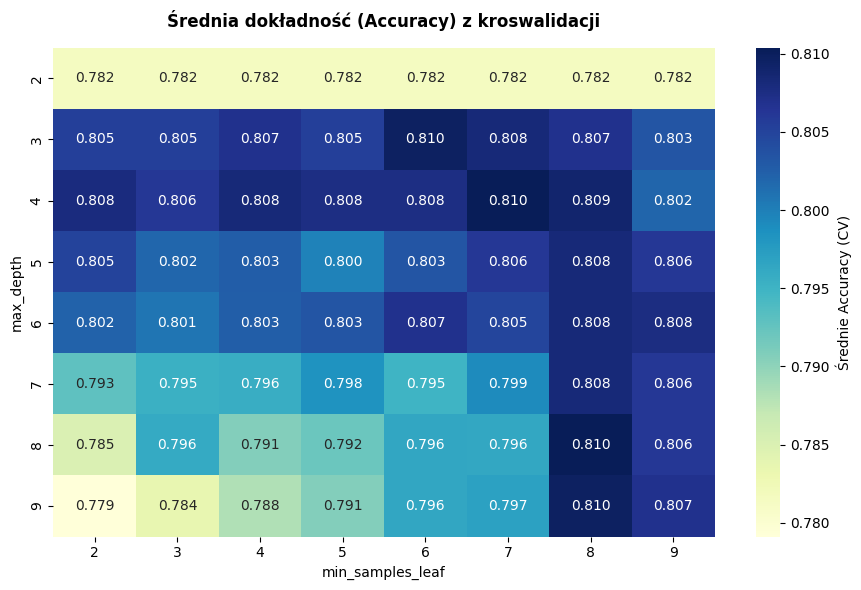

In [270]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results_df = pd.DataFrame(szukaj.cv_results_)

pivot_data = results_df.pivot_table(
    index='param_max_depth',
    columns='param_min_samples_leaf',
    values='mean_test_score',
    aggfunc='mean'
)

plt.figure(figsize=(9, 6))
sns.heatmap(pivot_data, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Średnie Accuracy (CV)'})

plt.title('Średnia dokładność (Accuracy) z kroswalidacji', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('min_samples_leaf', fontsize=10)
plt.ylabel('max_depth', fontsize=10)

plt.tight_layout()
plt.show()

Model osiąga podobne parametry (accuracy , precision, recall) dla zbioru treningowego i testowego, co świadczy o dobrym wytrenowaniu modelu. Potwierdza to powyższa macierz, dla której dla naszej wartości wybranych parametrów średnie accuracy jest najwyższe.

### 4. K-Nearest Neighbors

Dla KNN dane trzeba zeskalować, ponieważ duże wartości będą zaburzać wyniki.

In [271]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Analogicznie sprawdzę, dla których hiperparametrów model osiąga najlepsze wyniki

In [272]:
siatka_knn = {
    'n_neighbors': range(1, 21),
    'metric': ['euclidean', 'manhattan']
}
szukaj_knn = GridSearchCV(
    KNeighborsClassifier(),
    siatka_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1)
szukaj_knn.fit(X_train_scaled, y_train)
print("najlepsze ustawienia:", szukaj_knn.best_params_)
print("wynik kroswalidacji: ", round(szukaj_knn.best_score_, 3))
print("wynik na tescie:     ", round(szukaj_knn.score(X_test_scaled, y_test), 3))

najlepsze ustawienia: {'metric': 'euclidean', 'n_neighbors': 11}
wynik kroswalidacji:  0.817
wynik na tescie:      0.81


Dla danych testowych najlepsze hiperparametry to:
'metric': 'euclidean', 'n_neighbors': 11
Sprawdzę teraz dla tych parametrów, jakie są wyniki dla danych treningowych i dla danych testowych.

In [273]:
knn_model = KNeighborsClassifier(n_neighbors=11, metric='euclidean')
knn_model.fit(X_train_scaled, y_train)

print('wyniki dla zbioru treningowego')
y_pred = knn_model.predict(X_train_scaled)
print(classification_report(y_train, y_pred))
print(confusion_matrix(y_train, y_pred))

print('wyniki dla zbioru testowego')
y_pred = knn_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

wyniki dla zbioru treningowego
              precision    recall  f1-score   support

           0       0.84      0.91      0.87       444
           1       0.82      0.72      0.77       268

    accuracy                           0.84       712
   macro avg       0.83      0.81      0.82       712
weighted avg       0.84      0.84      0.83       712

[[403  41]
 [ 75 193]]
wyniki dla zbioru testowego
              precision    recall  f1-score   support

           0       0.83      0.85      0.84       105
           1       0.78      0.76      0.77        74

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

[[89 16]
 [18 56]]


Analogicznie model osiąga podobne parametry (accuracy, precision, recall) dla zbioru treningowego i testowego, co świadczy o dobrym wytrenowaniu modelu.

Zrobię wizualizaję tych dwóch hiperparametrów.

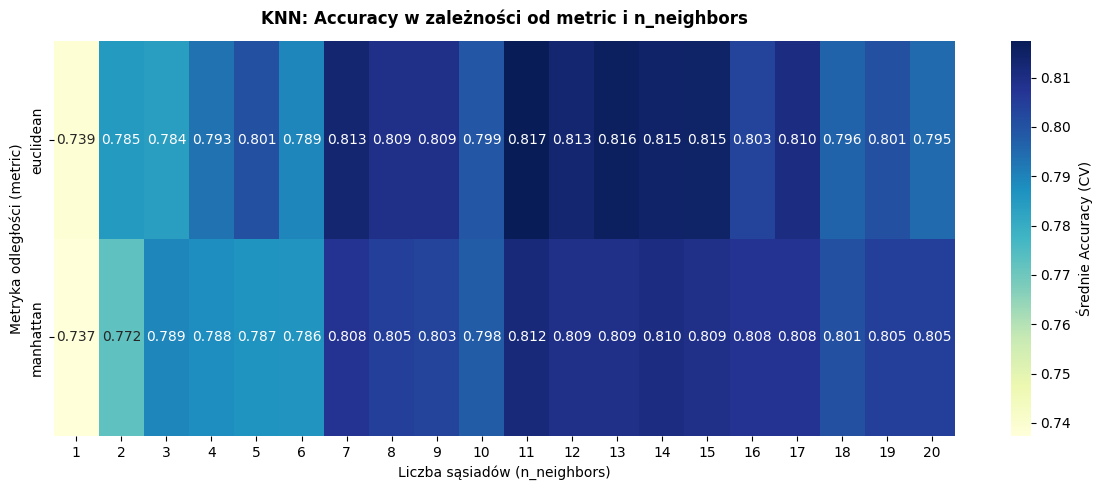

In [274]:
df_res = pd.DataFrame(szukaj_knn.cv_results_)

df_res['n_neighbors'] = [p['n_neighbors'] for p in df_res['params']]
df_res['metric'] = [p['metric'] for p in df_res['params']]

pivot_knn = df_res.pivot(index='metric', columns='n_neighbors', values='mean_test_score')

# Rysowanie wykresu
plt.figure(figsize=(12, 5))
sns.heatmap(pivot_knn, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Średnie Accuracy (CV)'})

plt.title('KNN: Accuracy w zależności od metric i n_neighbors', fontsize=12, fontweight='bold', pad=12)
plt.xlabel('Liczba sąsiadów (n_neighbors)', fontsize=10)
plt.ylabel('Metryka odległości (metric)', fontsize=10)

plt.tight_layout()
plt.show()


### 5. Wnioski

Oba modele osiągnęły wyniki na poziomie wyższym niż model bazowy. Ich skuteczność wynosiła dla różnych metryk ok. 70-80% Nie doszło do overfittingu, ponieważ wyniki były porównywalne zarówno dla zbiorów treingowych, jak i testowych.